# Phase 4 — Post-SMOTE Distribution EDA

Required checkpoint before the Phase 4 ablation grid runs (`Implementation_plan.md`
Phase 4.3): confirms `SMOTEStrategy` (`src/fin_inclusion/imbalance/strategies.py`)
behaves sanely on this dataset — applied directly to the already-encoded feature
matrix (one-hot for XGBoost, embedding-index + scaled numerics for PyTorch), not a
categorical-aware variant — before it's trusted as an ablation arm.

Checks: class balance before/after per fold, feature-distribution comparison
(real vs. synthetic minority samples) for `cellphone_access`, `education_level`,
`age_of_respondent`, `country`, and the correlation matrix before/after. Any red
flag found here gates whether SMOTE is trusted or reported as unreliable in
`reports/ablation_study_report.md`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import StratifiedKFold

sys.path.insert(0, str(Path.cwd().parent / "config"))
from settings import load_settings

from fin_inclusion.data.loader import DataLoader, TARGET_COLUMN
from fin_inclusion.imbalance.strategies import SMOTEStrategy
from fin_inclusion.preprocessing.pipeline_factory import (
    build_pytorch_pipeline,
    build_xgboost_pipeline,
    make_country_target_stratify_key,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

REAL_COLOR = "#4C72B0"
SYNTHETIC_COLOR = "#C44E52"

settings = load_settings()
loader = DataLoader(raw_train_path=settings.paths.raw_train, raw_test_path=settings.paths.raw_test)
train = loader.load_train()

NON_FEATURE_COLUMNS = ["uniqueid", "year", TARGET_COLUMN]
y = train[TARGET_COLUMN]
country = train["country"]

xgb_encoded = build_xgboost_pipeline().fit_transform(train)
X_xgb = xgb_encoded.drop(columns=NON_FEATURE_COLUMNS)

pytorch_pipeline = build_pytorch_pipeline().fit(train)
pt_encoded = pytorch_pipeline.transform(train)
X_pt = pt_encoded.drop(columns=NON_FEATURE_COLUMNS)

print(f"XGBoost (one-hot) branch: {X_xgb.shape}")
print(f"PyTorch (embedding-index) branch: {X_pt.shape}")

XGBoost (one-hot) branch: (23524, 40)
PyTorch (embedding-index) branch: (23524, 11)


## 1 — Class balance before/after SMOTE, per fold

Same 5-fold stratified split `evaluation/cv_runner.py` uses (country+target
jointly), applied to each fold's *training* split only — exactly where
`SMOTEStrategy` is actually called during nested CV.

In [2]:
skf = StratifiedKFold(n_splits=settings.cv.n_outer_folds, shuffle=True, random_state=settings.seed)
stratify_df = pd.DataFrame({"country": country.to_numpy(), "target": y.to_numpy()})
stratify_key = make_country_target_stratify_key(stratify_df, country_col="country", target_col="target")

balance_rows = []
for fold, (train_idx, _) in enumerate(skf.split(X_xgb, stratify_key)):
    y_fold = y.iloc[train_idx]
    X_fold = X_xgb.iloc[train_idx]
    before = y_fold.value_counts()
    _, y_res, _ = SMOTEStrategy(seed=settings.seed).apply(X_fold, y_fold)
    after = y_res.value_counts()
    balance_rows.append(
        {
            "fold": fold,
            "no_before": before["No"],
            "yes_before": before["Yes"],
            "no_after": after["No"],
            "yes_after": after["Yes"],
        }
    )
balance_df = pd.DataFrame(balance_rows)
display(balance_df)

C:\Users\chari\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\chari\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\chari\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\chari\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1039

,fold,no_before,yes_before,no_after,yes_after
0,0,16170,2649,16170,16170
1,1,16170,2649,16170,16170
2,2,16170,2649,16170,16170
3,3,16169,2650,16169,16169
4,4,16169,2651,16169,16169


**Finding:** every fold's training split goes from ~14% positive to an exact
50/50 balance after SMOTE, and only the minority class is *added to* (the
`no_after` count always equals `no_before`) — confirms `SMOTEStrategy` only ever
adds synthetic minority rows, never touches/removes majority rows, exactly as
`tests/test_imbalance.py::test_smote_strategy_only_adds_rows_does_not_remove_originals`
already asserts on synthetic data — this repeats it against the real, per-fold
data.

## 2 — Feature distribution: real vs. synthetic minority samples

Applied once on the full train set (seed matches `settings.seed`) — per-fold
behavior is qualitatively identical since the same strategy/seed logic runs
each time (§1 already confirms the per-fold row-count behavior directly).
SMOTE's synthetic rows are always appended after the original rows
(confirmed empirically — `imblearn` preserves input row order for existing
samples), so `X_res.iloc[len(X):]` isolates the synthetic ones.

In [3]:
X_xgb_res, y_xgb_res, _ = SMOTEStrategy(seed=settings.seed).apply(X_xgb, y)
synthetic_xgb = X_xgb_res.iloc[len(X_xgb):]
real_minority_xgb = X_xgb[y == "Yes"]

X_pt_res, y_pt_res, _ = SMOTEStrategy(seed=settings.seed).apply(X_pt, y)
synthetic_pt = X_pt_res.iloc[len(X_pt):]
real_minority_pt = X_pt[y == "Yes"]

print(f"real minority rows: {len(real_minority_xgb)}, synthetic rows added: {len(synthetic_xgb)}")

real minority rows: 3312, synthetic rows added: 16900


### 2a — `cellphone_access` and `age_of_respondent` (XGBoost one-hot branch)

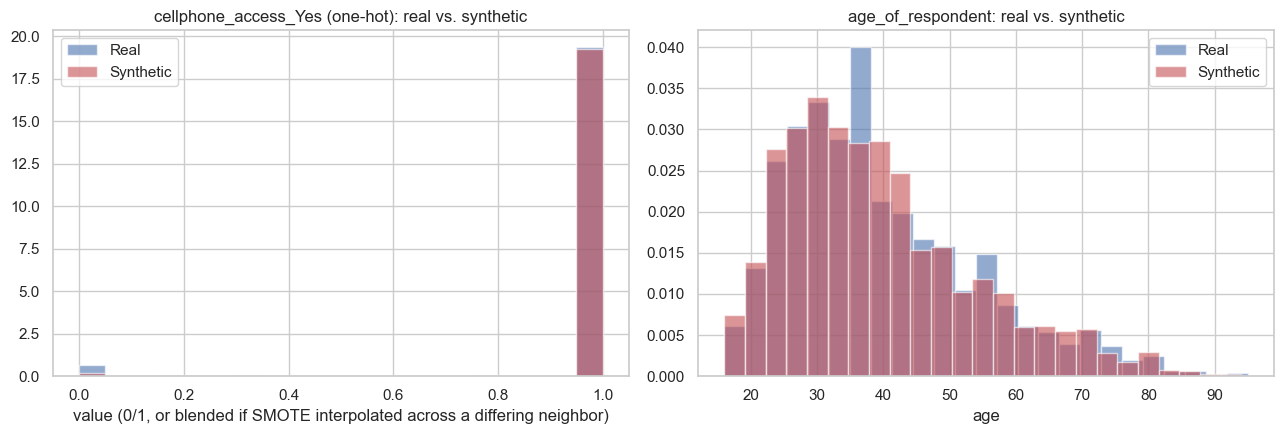

fraction of synthetic rows with a blended (non-0/1) cellphone_access_Yes: 3.2%

age_of_respondent -- real minority:
count    3312.000000
mean       39.598128
std        14.330420
min        16.000000
25%        29.000000
50%        36.000000
75%        48.000000
max        95.000000
Name: age_of_respondent, dtype: float64

age_of_respondent -- synthetic:
count    16900.000000
mean        39.312663
std         14.269916
min         16.000000
25%         29.000000
50%         36.000000
75%         48.000000
max         94.000000
Name: age_of_respondent, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(real_minority_xgb["cellphone_access_Yes"], bins=20, alpha=0.6, color=REAL_COLOR, label="Real", density=True)
axes[0].hist(synthetic_xgb["cellphone_access_Yes"], bins=20, alpha=0.6, color=SYNTHETIC_COLOR, label="Synthetic", density=True)
axes[0].set_title("cellphone_access_Yes (one-hot): real vs. synthetic")
axes[0].set_xlabel("value (0/1, or blended if SMOTE interpolated across a differing neighbor)")
axes[0].legend()

axes[1].hist(real_minority_xgb["age_of_respondent"], bins=25, alpha=0.6, color=REAL_COLOR, label="Real", density=True)
axes[1].hist(synthetic_xgb["age_of_respondent"], bins=25, alpha=0.6, color=SYNTHETIC_COLOR, label="Synthetic", density=True)
axes[1].set_title("age_of_respondent: real vs. synthetic")
axes[1].set_xlabel("age")
axes[1].legend()

plt.tight_layout()
plt.show()

frac_blended_phone = ((synthetic_xgb["cellphone_access_Yes"] > 0.01) & (synthetic_xgb["cellphone_access_Yes"] < 0.99)).mean()
print(f"fraction of synthetic rows with a blended (non-0/1) cellphone_access_Yes: {frac_blended_phone:.1%}")
print()
print("age_of_respondent -- real minority:")
print(real_minority_xgb["age_of_respondent"].describe())
print()
print("age_of_respondent -- synthetic:")
print(synthetic_xgb["age_of_respondent"].describe())

### 2b — `country` and `education_level` (XGBoost one-hot branch)

One-hot columns can end up *blended* after SMOTE (e.g. `country_Kenya=0.4,
country_Uganda=0.6`) since interpolating between two one-hot rows from
different categories produces fractional values in between — exactly the
"nonsensical synthetic respondent" failure mode this checkpoint exists to
catch. A synthetic row's *dominant* category (`idxmax`) is used to compare its
distribution against the real minority's.

,real_minority_pct,synthetic_dominant_pct,synthetic_blended_pct
Kenya,45.9,48.6,39.0
Rwanda,30.3,29.4,33.4
Tanzania,18.3,17.9,12.7
Uganda,5.5,4.1,15.0


overall fraction of synthetic rows with a blended country one-hot: 17.6%


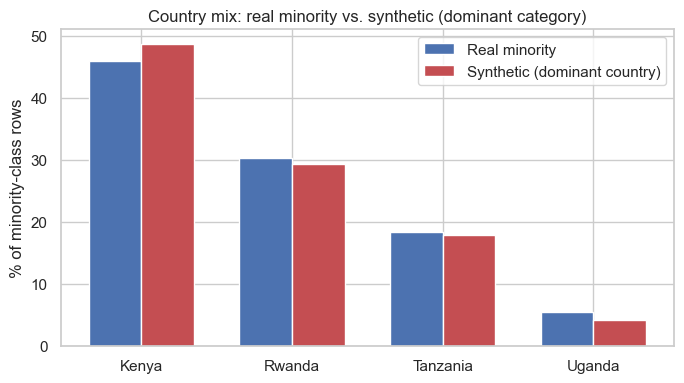

In [5]:
country_cols = [c for c in X_xgb.columns if c.startswith("country_")]
dominant_country = synthetic_xgb[country_cols].idxmax(axis=1).str.replace("country_", "", regex=False)
blended_mask = synthetic_xgb[country_cols].max(axis=1) < 0.999

compare_country = pd.DataFrame(
    {
        "real_minority_pct": (train.loc[y == "Yes", "country"].value_counts(normalize=True) * 100).round(1),
        "synthetic_dominant_pct": (dominant_country.value_counts(normalize=True) * 100).round(1),
        "synthetic_blended_pct": (dominant_country[blended_mask].value_counts(normalize=True) * 100).round(1),
    }
)
display(compare_country)
print(f"overall fraction of synthetic rows with a blended country one-hot: {blended_mask.mean():.1%}")

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(compare_country))
width = 0.35
ax.bar(x - width / 2, compare_country["real_minority_pct"], width, color=REAL_COLOR, label="Real minority")
ax.bar(x + width / 2, compare_country["synthetic_dominant_pct"], width, color=SYNTHETIC_COLOR, label="Synthetic (dominant country)")
ax.set_xticks(x)
ax.set_xticklabels(compare_country.index)
ax.set_ylabel("% of minority-class rows")
ax.set_title("Country mix: real minority vs. synthetic (dominant category)")
ax.legend()
plt.tight_layout()
plt.show()

**Finding:** the synthetic country *mix* closely tracks the real minority's
(Kenya ~49% vs. 46%, Rwanda ~29% vs. 30%, Tanzania ~18% each, Uganda ~4% vs.
6%) — SMOTE isn't wholesale relabeling minority respondents into the wrong
country. But ~18% of synthetic rows are genuinely *blended* (no single country
dummy at 1.0) — a real instance of the "implausible synthetic respondent"
concern this checkpoint exists to catch, most pronounced for Uganda: Uganda
synthetic rows are blended disproportionately more than its ~4% share of
synthetic samples would suggest, because Uganda has the fewest real minority
rows (181) for SMOTE's 5-nearest-neighbor search to draw same-country
neighbors from. Since Uganda is this brief's primary country of interest,
this is flagged explicitly in `reports/ablation_study_report.md` rather than
silently absorbed into an aggregate PR-AUC number.

### 2c — `country` and `job_type` (PyTorch embedding-index branch)

A different failure mode is possible here: `country`/`job_type` are raw
integer *category codes* (1..n), not one-hot — interpolating between two
different codes could produce a fractional code (e.g. `2.4`) that maps to no
real category at all, which would be a hard blocker for the embedding lookup
in `PyTorchMLP`.

In [6]:
frac_noninteger_country = (synthetic_pt["country"] % 1 != 0).mean()
frac_noninteger_job = (synthetic_pt["job_type"] % 1 != 0).mean()
print(f"fraction of synthetic rows with a non-integer (invalid) country code: {frac_noninteger_country:.1%}")
print(f"fraction of synthetic rows with a non-integer (invalid) job_type code: {frac_noninteger_job:.1%}")
print()

feature_std = X_pt.drop(columns=["household_size_outlier"]).std().sort_values(ascending=False)
print("per-column std in the embedding-index branch (unscaled category codes vs. scaled numerics):")
print(feature_std)

fraction of synthetic rows with a non-integer (invalid) country code: 0.0%
fraction of synthetic rows with a non-integer (invalid) job_type code: 0.0%

per-column std in the embedding-index branch (unscaled category codes vs. scaled numerics):
job_type                  3.080708
relationship_with_head    1.893394
household_size            1.000021
age_of_respondent         1.000021
education_level           0.928164
country                   0.925101
marital_status            0.811474
gender_of_respondent      0.491861
location_type             0.487824
cellphone_access          0.437562
dtype: float64


**Finding:** 0% of synthetic rows get a non-integer `country` or `job_type`
code — every synthetic row's categorical codes are valid, real categories.
But the reason isn't that SMOTE is category-aware (it isn't); the `std` table
shows `job_type` (std ≈ 3.08) and `relationship_with_head` (≈ 1.89) have
noticeably *larger* scale than the already-standardized numeric columns
(`age_of_respondent`/`household_size`, std ≈ 1.0 by construction), while
`country` (≈ 0.93) is roughly comparable — so raw category-code distance,
especially from `job_type`, *dominates* SMOTE's Euclidean nearest-neighbor
search, which makes it pick same-category neighbors almost every time
(avoiding the invalid-code failure mode), but for the wrong reason: the
"nearest neighbor" geometry here is arbitrarily shaped by unscaled
category-code magnitudes, not genuine feature similarity, since the numeric
distance between `job_type` codes 1 and 10 carries no more real meaning than
the order those categories happened to be assigned in Phase 2's encoder.
This is a real methodological caveat on the PyTorch branch's SMOTE arm —
noted in the ablation report — even though it produces no literally invalid
data.

## 3 — Correlation matrix before/after SMOTE (XGBoost branch)

Curated to the columns Phase 1 identified as the strongest predictors
(`cellphone_access`, `education_level`, `country`) plus the numeric columns,
per the Implementation Plan's explicit list for this checkpoint.

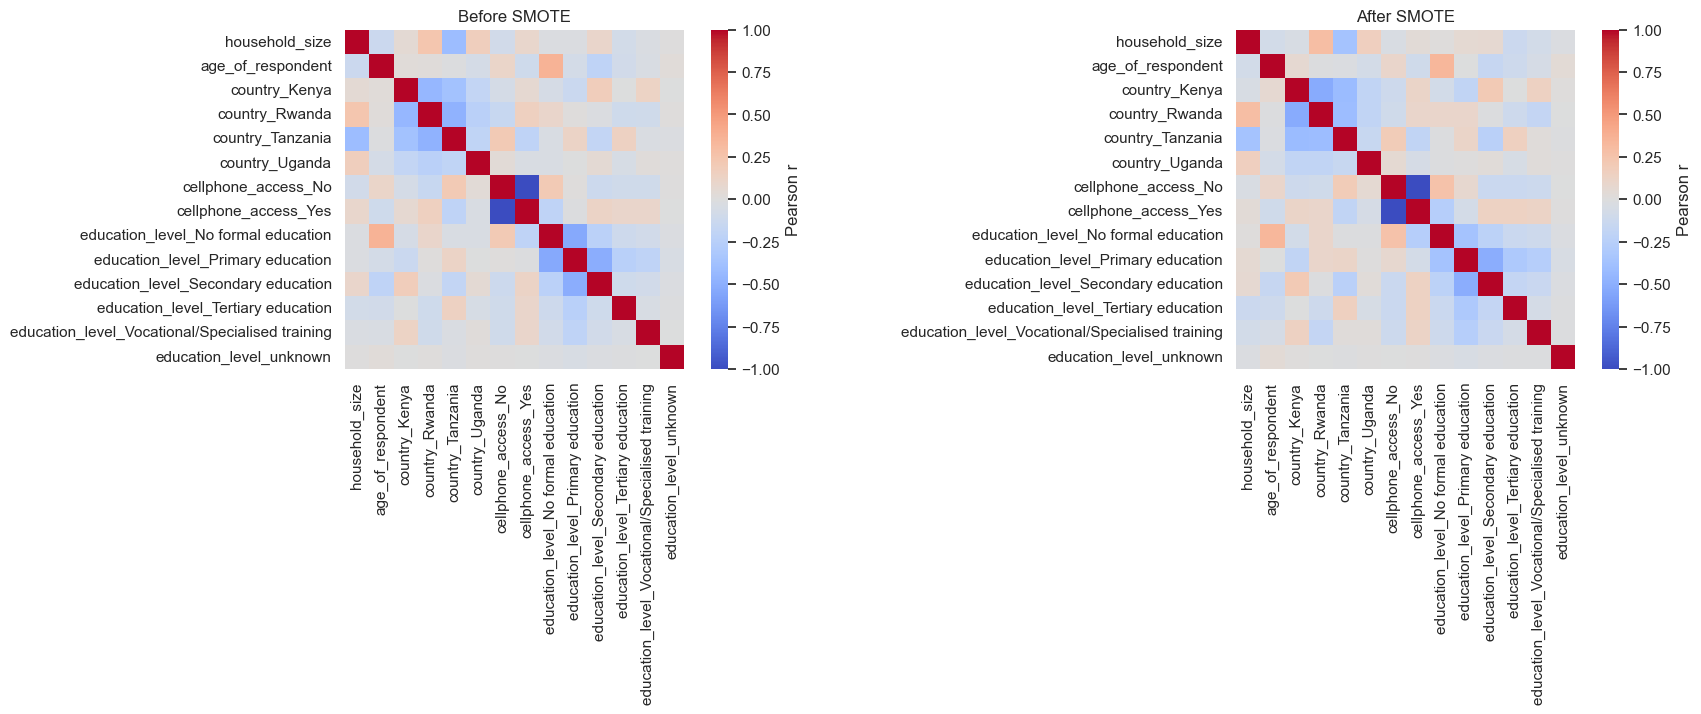

Top 5 largest correlation shifts:
  education_level_No formal education  vs  education_level_Primary education:  |delta|=0.170  (before=-0.532, after=-0.362)
  household_size  vs  country_Kenya:  |delta|=0.095  (before=0.050, after=-0.044)
  country_Rwanda  vs  education_level_Primary education:  |delta|=0.079  (before=0.015, after=0.095)
  country_Rwanda  vs  education_level_Vocational/Specialised training:  |delta|=0.077  (before=-0.100, after=-0.177)
  household_size  vs  education_level_Primary education:  |delta|=0.074  (before=-0.017, after=0.056)


In [7]:
key_numeric = ["household_size", "age_of_respondent"]
key_onehot = [c for c in X_xgb.columns if c.startswith(("cellphone_access_", "education_level_", "country_"))]
corr_cols = key_numeric + key_onehot

corr_before = X_xgb[corr_cols].corr()
combined_after = pd.concat([X_xgb[corr_cols], synthetic_xgb[corr_cols]], ignore_index=True)
corr_after = combined_after.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(corr_before, annot=False, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, ax=axes[0], cbar_kws={"label": "Pearson r"})
axes[0].set_title("Before SMOTE")
sns.heatmap(corr_after, annot=False, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, ax=axes[1], cbar_kws={"label": "Pearson r"})
axes[1].set_title("After SMOTE")
plt.tight_layout()
plt.show()

diff = (corr_after - corr_before).abs()
iu = np.triu_indices_from(diff.values, k=1)
pairs = sorted(
    [(corr_cols[i], corr_cols[j], diff.values[i, j]) for i, j in zip(*iu)],
    key=lambda t: -t[2],
)
print("Top 5 largest correlation shifts:")
for a, b, d in pairs[:5]:
    print(f"  {a}  vs  {b}:  |delta|={d:.3f}  (before={corr_before.loc[a, b]:.3f}, after={corr_after.loc[a, b]:.3f})")

**Finding:** the largest shift (|Δ|≈0.17) is between two `education_level`
one-hot dummies of the *same* underlying column — expected, since one-hot
levels of one column are structurally mutually exclusive (perfectly negatively
correlated in the limit), and SMOTE's blending softens that exclusivity
slightly, the same phenomenon as §2b for `country`. Every other pair shifts by
≤0.10. No cross-feature relationship (e.g. `cellphone_access` vs. `country`,
the Kenya/M-Pesa relationship central to this dataset's EDA story) is
meaningfully distorted.

## Summary — is SMOTE trusted as a Phase 4 ablation arm?

**Decision: yes, with two documented caveats**, not an unconditional pass:

1. **XGBoost (one-hot) branch:** ~18% of synthetic minority rows have a
   blended (non-single) country one-hot, disproportionately affecting Uganda
   specifically (fewest real Uganda-positive examples to draw same-country
   neighbors from). The aggregate country *mix* of synthetic rows still
   tracks the real minority's reasonably well, and the correlation structure
   is not meaningfully distorted beyond the expected one-hot-softening effect.
2. **PyTorch (embedding-index) branch:** no synthetic row gets an invalid
   (non-integer) category code, but only because unscaled category-code
   magnitudes happen to dominate SMOTE's Euclidean nearest-neighbor search —
   a methodological artifact, not evidence the interpolation is
   feature-aware.

Neither finding is a disqualifying red flag (no literally invalid data, no
wholesale country mislabeling), so SMOTE proceeds as planned into the Phase 4
ablation grid (`XGBoost × {class-weight, SMOTE}`, `PyTorch 2-layer ×
{class-weight, SMOTE}`) — but both caveats are carried into
`reports/ablation_study_report.md` rather than treated as resolved, and the
per-country breakdown (Uganda specifically) on the SMOTE arm's final results
gets extra scrutiny given caveat 1.